# Query Baseline

Generierung der Antworten zu den gewählten Beispiel-Fragen aus dem Datensatz durch die Large-Language-Modelle ohne Verwendung der Retrieval-Komponente und Ähnlichkeit mit Referenz-Antworten berechnen.

**Voraussetzung**

Environment: dski

LLMs und Emebdding-Modell mittels vLLM über Rest-API zur Verfügung stellen (siehe setup.md).

**Versuchsaufbau**

Die verwendete Stichprobe umfasst 397 gewählte Fragen aus dem Datensatz.

Die Fragen werden mit dem entwickelten Prompt und ermittelten Parameter-Wert von 0.3 für die Sampling-Methode temperature nacheinander in die beiden Sprachmodelle eingegeben.

Für die erzeugten Modell- sowie die Referenz-Antworten werden durch das Embedding-Modell Text-Embeddings erzeugt und mittels Vector-Similarity die Ähnlichkeit zwischen diesen berechnet.

## Setup

### Pakete laden

In [1]:
import config

import numpy as np
import pandas as pd
import regex as re

import pyarrow as pa
import pyarrow.parquet as pq

from openai import OpenAI

import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from util.px import PX
from util.helper import Helper

### Variablen+Funktionen

In [2]:
# Namen der Modelle für Ausgabe in Tabellen und Plots
models = ['Ministral-8B-Instruct-2410', 'Llama-3.1-8B-Instruct']

# Farbwerte für Plots
model_colors = ['#FF0000', '#0000FF']#['#B6B7F7', '#E9AFA2']

# OpenAI LLM client
openai_client = OpenAI(
    base_url=config.openai_client['chat']['base_url'],
    api_key=config.openai_client['api_key']
)

# OpenAI Embedding-Modell client
openai_client_embedding = OpenAI(
    base_url=config.openai_client['embedding']['base_url'],
    api_key=config.openai_client['api_key']
)

### Sample

Funktion zur Ausgabe einzelner Frage aus Datensatz mit Modell- und Referenz-Antwort

In [3]:
def get_sample(index, model_select):
    # Generator-LLM
    model_name = config.models['generation'][model_select][config.models['generation'][model_select].index('/') + 1: ]
    
    # Modell-Antworten laden
    answers_model = pq.read_table(f'{config.dataset["path"]}answers_model_{model_name}_baseline.parquet').to_pandas()
    
    print(f'index: {index}')
    print(f'---\nmodel: {model_name}')
    print('---\nquery\n')
    #print(queries_answers_select.loc[answer_len_diff_abs_index].iloc[index]['query'])
    print(queries_text_text_table_select.loc[index]['query'])
    print('---\nanswer reference\n')
    print(queries_text_text_table_select.loc[index]['answer'])
    print('---\nanswer model\n')
    #print(answers_model.loc[queries_text_text_table_select.iloc[index].name]['answer_model'])
    print(answers_model.loc[index, 'answer_model'])
    print(f'---\nanswer similarity: {answers_model.loc[index, 'answer_similarity']}')

### Daten laden

In [4]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

source=text|text-table
und word_len>=8

In [5]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Punctuation entfernen
# ein oder mehrere Zeilenumbrüche, Tabulatoren und Leerzeichen durch ein Leerzeichen ersetzen
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()
# Anzahl Zeichen
#queries_answers['answer_len'] = queries_answers['answer'].str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]#.sample(n=samples, axis=0, random_state=42)

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

Anzahl Fragen vor und nach Bereinigung der Dokumente

In [ ]:
# Anzahl Fragen source=text|text-table und answer_word_count>=8

# 1/1
#print(queries_text_text_table.shape[0])
#1719

# 1/4
#print(queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).shape[0])
#430

In [ ]:
# Anzahl Dokumente, auf die sich die gewählten Fragen beziehen

# 1/1
#print(qrels.loc[queries_text_text_table.index]['doc_id'].unique().shape[0])
#385

# 1/4
#print(qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]['doc_id'].unique().shape[0])
#266

In [ ]:
# Anzahl gewählter Fragen, für welche die Dokumente aus dem Datensatz entfernt wurden

# 1/1
#qrels_select = qrels.loc[queries_text_text_table.index]
#print(qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index].shape[0])
#148

# 1/4
#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#print(qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index].shape[0])
#33

In [ ]:
# Anzahl gewählter Fragen, für welche bereinigte Dokumente vorhanden sind

# 1/1
#qrels_select = qrels.loc[queries_text_text_table.index]
#qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]
#print(queries_text_text_table.loc[~queries_text_text_table.index.isin(qrels_select.index)].shape[0])
#1571 (1719 - 148)

# 1/4
#qrels_select = qrels.loc[queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index]
#qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]
#print(queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).loc[~queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42).index.isin(qrels_select.index)].shape[0])
#397 (430 - 33)

In [6]:
# Fragen ausschließen, welche sich auf ausgeschlossene Dokumente beziehen

# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle gewählten Fragen selektieren
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels.loc[qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index]

# Fragen selektieren für die index nicht in qrels_select index
queries_text_text_table_select = queries_text_text_table.loc[~queries_text_text_table.index.isin(qrels_select.index)]

## Generierung

### Antworten generieren

Generierung der Antworten durch die Sprachmodelle mit dem entwickelten Prompt und der Sampling-Methode temperature mit einem Parameter-Wert von 0.3 Antworten ohne Verwendung der Retrieval-Komponente zu den gewählten 397 Fragen.

Modell-Antworten als Pandas DataFrame im parquet-Format speichern.

In [7]:
# LLM
model = config.models['generation'][0]

model_file_name = model[model.index('/') + 1:]

In [ ]:
# Neuen Dataframe mit identischem Index aus answers-Dataframe zur Speicherung der Antworten des Modells erzeugen
answers_model = pd.DataFrame({'answer_model': '', 'answer_similarity': 0.0}, index=answers.index)

# System-Prompt
prompt_system = 'Users submit questions regarding various topics and fields related to scientific publications. The aim is to assist users in answering these questions. The answers should be concise and contain only the most important information.'

# über Fragen iterieren
for i in range(queries_text_text_table_select.shape[0]):
    print(f'Frage {i}')
    query = queries_text_text_table_select.iloc[i]
    
    # Antwort durch LLM generieren
    # Request über OpenAI-Client an vLLM Rest-API senden
    response = openai_client.chat.completions.create(
        model=model,
        temperature=0.3,
        max_tokens=2048,
        stream=False,
        messages=[
            {'role': 'system', 'content': prompt_system}, 
            {'role': 'user', 'content': query['query']}
        ],
    )
    
    # Modell-Antwort zu Frage in Dataframe speichern
    answers_model.loc[query.name, 'answer_model'] = response.choices[0].message.content

# Dataframe mit Modell-Antworten im parquet-Format speichern
answers_model_table = pa.Table.from_pandas(answers_model)
pq.write_table(answers_model_table, f'{config.dataset["path"]}answers_model_{model_file_name}_baseline.parquet')#, compression='GZIP'

### Vector-Similarity

Erzeugung der Text-Emeddings für Modell- und Referenz-Antworten und Berechung der Ähnlichkeit mittels Vector-Similarity und Dot-Product zwischen den Antworten.

Embedding-Vektoren zu DataFrame mit Modell-Antworten hinzufügen.

In [ ]:
# Embeddings für Referenz-Antworten erzeugen
embeddings_answer = openai_client_embedding.embeddings.create(
    input=answers.loc[queries_text_text_table_select.index, 'answer'],
    model=config.models['embedding'][0]
)

answers_model_file_name = f'{config.dataset["path"]}answers_model_{model_file_name}_baseline.parquet'

# Datei mit Modell-Antworten in Dataframe einlesen
answers_model = pq.read_table(answers_model_file_name).to_pandas()

# Embeddings für Modell-Antworten erzeugen
embeddings_answer_model = openai_client_embedding.embeddings.create(
    input=answers_model.loc[queries_text_text_table_select.index, 'answer_model'],
    model=config.models['embedding'][0]
)

# Über Antworten iterieren
for i in range(queries_text_text_table_select.shape[0]):
    # Dot-Product für Embedding-Vektoren der Modell- und Referenz-Antwort berechnen
    answers_model.loc[queries_text_text_table_select.iloc[i].name, 'answer_similarity'] = np.dot(embeddings_answer.data[i].embedding, embeddings_answer_model.data[i].embedding)

# Dataframe mit Modell-Antworten im parquet-Format speichern
answers_model_table = pa.Table.from_pandas(answers_model)
pq.write_table(answers_model_table, answers_model_file_name)#, compression='GZIP'

In [8]:
get_sample(
    index=queries_text_text_table_select.iloc[10].name, 
    model_select=0
)

index: 888bb3d1-ff12-4225-ae76-21cd4c8c8973
---
model: Ministral-8B-Instruct-2410
---
query

Does NVILA reduce training costs compared to other VLMs?
---
answer reference

Yes, NVILA reduces training costs by $1.9 - 5.1 \times$.
---
answer model

Yes, NVILA (Neural Vector Inference for Language Analysis) can reduce training costs compared to other Vector Language Models (VLMs) due to its efficient inference mechanisms and reduced computational requirements. NVILA leverages vector-based representations and inference techniques that are less resource-intensive, making it a cost-effective alternative for certain applications.
---
answer similarity: 0.6666056607681226


### Stats

Ausgabe statistischer Kennzahlen zu den berechneten Ähnlichkeiten zwischen Modell- und Referenz-Antworten und Visualisierung der Ergebnisse.

Das Ergebnis der Berechnung der Ähnlichkeiten mittels Vector-Similarity und Dot-Product ist eine kontinuierliche reele Zahl im Bereich von -1.0 (keine Ähnlichkeit) bis 1.0 (vollständige Ähnlichkeit). Die Auswertung kann in Form statistischer Kennzahlen wie dem Durchschnittswert, Median, Minimal- und Maximal-Werten, der Standardabweichung, Berechnung der Quantile und Darstellung der Verteilung in Form von Box- oder Violin-Plots erfolgen. Weiterhin können die Ähnlichkeiten der Antworten beider Sprachmodelle sowie Eigenschaften wie die Anzahl der Wörter der Modell-Antworten sowie deren Differenz gegenüber der Anzahl der Wörter der Referenz-Antworten beispielsweise in Form von Scatter-Plots gegenübergestellt werden.

In [9]:
# Daten einlesen

# Dictionary für Werte
output = {
    'model': [], 
    'answer_similarity': []
}

# Modelle
for m in models:
    # Modell-Antworten laden
    a_m = pq.read_table(f'{config.dataset["path"]}answers_model_{m}_baseline.parquet').to_pandas()
    # Werte zu Ditionary hinzufügen
    output['model'].extend([m] * queries_text_text_table_select.shape[0])
    output['answer_similarity'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_similarity'])# Anzahl Wörter für Fragen 
    #output['answer_word_count'].extend(a_m.loc[queries_text_text_table_select.index, 'answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()

df = pd.DataFrame.from_dict(output).convert_dtypes()

In [10]:
df.groupby(by=['model'])['answer_similarity'].describe()#.agg(['mean', 'min', 'max', 'std', 'median'])#

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Llama-3.1-8B-Instruct,397.0,0.597844,0.131519,0.151518,0.515454,0.607919,0.693026,0.859845
Ministral-8B-Instruct-2410,397.0,0.617154,0.14211,0.123391,0.52957,0.628102,0.71757,0.993354


#### Box-/Violin-Plot Similarity Modell-/Referenz-Antwort

Gruppierten Box-Plot der Verteilung der Werte für die Ähnlichkeiten zwischen Modell- und Referenz-Antwort erstellen.

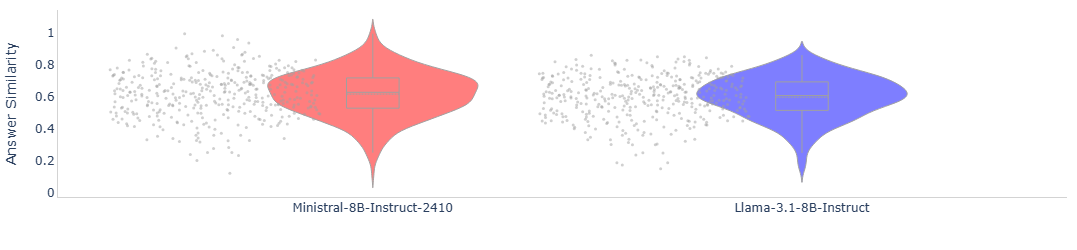

In [11]:
fig = go.Figure()

# Modelle
#for m in models:
for i in range(len(models)):
    m = models[i]
    # Box-Plot hinzufügen
    """fig.add_trace(
        go.Box(
            x=[m] * queries_text_text_table_select.shape[0],
            y=df.loc[df['model'] == m, 'answer_similarity'].to_list(),
            name=m,
            boxmean=True, 
            #text=,
            boxpoints='all',
            jitter=1,
            #marker_color=model_colors[r],
            width=0.5
        )
    )"""
    fig.add_trace(
        go.Violin(
            x=[m] * queries_text_text_table_select.shape[0],
            y=df.loc[df['model'] == m, 'answer_similarity'].to_list(),
            name=m,
            points='all',
            jitter=1,
            box_visible=True, 
            line={'color': '#444444', 'width': 1},
            meanline_visible=True, 
            opacity=0.5,
            fillcolor=model_colors[i]
        )
    )

fig.update_traces(marker={'size': 3, 'opacity': 0.5})

fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='LightGrey', title='Answer Similarity', dtick=0.2)
fig.update_xaxes(showline=True, linewidth=1, linecolor='LightGrey', title='')#, tickangle=10, tickson='boundaries'
        
fig.update_layout(
    width=450,
    height=250,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    #title='',
    showlegend=False,
    boxmode='group',
    #boxgroupgap=0.0, 
    #boxgap=0.0
)

fig.show()

Mit einem Wert von 0.617 wurde für die Antworten des Modells Ministral-8B-Instruct-2410 die höchste durchschnittliche Ähnlichkeit mit den Referenz-Antworten berechnet. Die Streuung der Werte ist relativ hoch, im Minimum beträgt die Ähnlichkeit 0.123 und im Maximum 0.993 mit einer Standardabweichung von 0.142.

Für die Antworten des Modells Llama-3.1-8B-Instruct ist die durchschnittliche Ähnlichkeit mit einem Wert von 0.5978 und der Maximal-Wert mit 0.8598 geringer. Der Minimal-Wert ist mit 0.1515 höher und die Standardabweichung fällt mit 0.13162 dementsprechend geringer aus.

| model | mean |std | min | 25% | 50% | 75% | max |
| - | - | - | - | - | - | - | - |
| Ministral-8B-Instruct-2410 | 0.617154 | 0.14211 | 0.123391 | 0.52957 | 0.628102 | 0.71757 | 0.993354 |
| Llama-3.1-8B-Instruct | 0.597844 | 0.131519 | 0.151518 | 0.515454 | 0.607919 | 0.693026 | 0.859845 |

Aufgrund der hohen berechneten Ähnlichkeit besteht die Vermutung, dass das Wissen zur Beantwortung der Fragen in den Parametern der Modelle vorhanden ist und entsprechende Texte, welche die Informationen beinhalten, für das Training verwendet wurden.

#### Modell-Vergleich

Gegenüberstellung der Ähnlichkeiten und Anzahl der Wörter für Sprachmodelle

In [12]:
# Antworten für beide Modelle laden
answers_model = [
    pq.read_table(f'{config.dataset["path"]}answers_model_Ministral-8B-Instruct-2410_baseline.parquet').to_pandas(),
    pq.read_table(f'{config.dataset["path"]}answers_model_Llama-3.1-8B-Instruct_baseline.parquet').to_pandas()
]

# Antworten zu Fragen-Auswahl selektieren
answers_model[0] = answers_model[0].loc[queries_text_text_table_select.index]
answers_model[1] = answers_model[1].loc[queries_text_text_table_select.index]

# Anzahl Wörter für Modell-Antworten
answers_model[0]['answer_word_count'] = answers_model[0]['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()
answers_model[1]['answer_word_count'] = answers_model[1]['answer_model'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True).str.split(' ').str.len()

# Differenz Anzahl Wörter Modell-/Referenz-Antwort
answers_model[0]['answer_word_count_diff'] = (answers_model[0]['answer_word_count'] - queries_text_text_table_select['answer_word_count'])#.abs()
answers_model[1]['answer_word_count_diff'] = (answers_model[1]['answer_word_count'] - queries_text_text_table_select['answer_word_count'])#.abs()

In [13]:
print(f'Differenz Anzahl Wörter Modell-/Referenz-Antwort {models[0]}')
print(answers_model[0]['answer_word_count_diff'].describe())

print(f'\nDifferenz Anzahl Wörter Modell-/Referenz-Antwort {models[1]}')
print(answers_model[1]['answer_word_count_diff'].describe())

Differenz Anzahl Wörter Modell-/Referenz-Antwort Ministral-8B-Instruct-2410
count    397.000000
mean      93.806045
std       74.482153
min       -6.000000
25%       33.000000
50%       64.000000
75%      154.000000
max      438.000000
Name: answer_word_count_diff, dtype: float64

Differenz Anzahl Wörter Modell-/Referenz-Antwort Llama-3.1-8B-Instruct
count     397.000000
mean      154.692695
std       113.741539
min        -8.000000
25%        99.000000
50%       150.000000
75%       197.000000
max      1588.000000
Name: answer_word_count_diff, dtype: float64


#### Scatter-Plot Similarity Models

Gegenüberstellung der berechneten Ähnlichkeiten zwischen LLMs.

Correlation

PearsonRResult(statistic=np.float64(0.8793971774196482), pvalue=np.float64(2.2163069536689213e-129))
SignificanceResult(statistic=np.float64(0.8853219613064176), pvalue=np.float64(1.9586477978338362e-133))



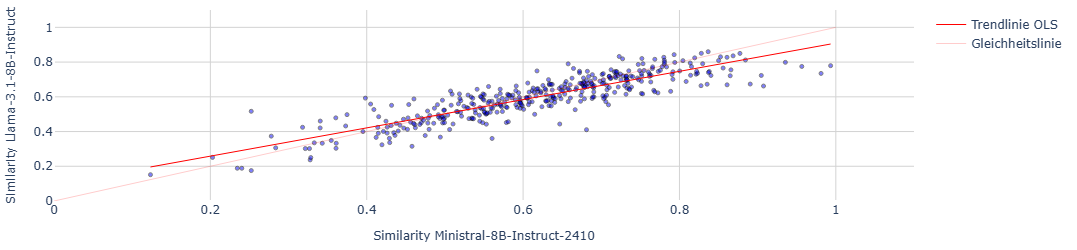

In [14]:
# Korrelation der Ähnlichkeiten zwischen Modellen
print('Correlation\n')
print(stats.pearsonr(answers_model[0]['answer_similarity'], answers_model[1]['answer_similarity']))
print(stats.spearmanr(answers_model[0]['answer_similarity'], answers_model[1]['answer_similarity']))
print('')

# Differenz der Ähnlichkeiten zwischen Modellen
#print('Differenz Ähnlichkeiten\n')
#print((answers_model[0]['answer_similarity'] - answers_model[1]['answer_similarity']).abs().describe())

# Scatter Plot Ähnlichkeiten der Antworten zwischen Modellen
fig = px.scatter(
    x=answers_model[0]['answer_similarity'], 
    y=answers_model[1]['answer_similarity'],
    opacity=0.5,
    trendline='ols',
    trendline_color_override='rgba(255, 0, 0, 1.0)'
)

fig.update_traces(line={'width': 1})#, selector={'mode': 'lines')

# Gleichheitslinie
fig.add_shape(
    type="line",
    x0=0.0, y0=0.0,
    x1=1.0, y1=1.0,
    line={'color': '#FF0000', 'width': 1},
    opacity=0.2,
    fillcolor='#FF0000'
)

fig.update_traces(marker={'color': '#0000FF', 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}})

# legende ols trendline
fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', line={'color': '#FF0000', 'width': 1}, name='Trendlinie OLS'))

# legende Gleichheitslinie
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", opacity=0.2, line={'color': '#FF0000', 'width': 1}, name='Gleichheitslinie'))

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': f'Similarity {models[1]}', 'font':{'size': 12}}, dtick=0.2, range=[0.0, 1.1])#, title='Answer-Similarity Retrieval'
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': f'Similarity {models[0]}', 'font':{'size': 12}}, dtick=0.2, range=[0.0, 1.1])#

fig.update_layout(
    width=450,
    height=250,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    showlegend=True
)

fig.show()

Für die durch das Modell Ministral-8B-Instruct-2410 erzeugten Antworten wurde gegenüber dem Modell Llama-3.1-8B-Instruct im Durchschnitt eine höhere Ähnlichkeit mit den Referenz-Antworten berechet. Zwischen den Ähnlichkeiten der Antworten für die beiden Modelle besteht mit einem Pearson- und Spearman Korrelationskoeffizient von 0.8794 und 0.885 insgesamt ein starker positiver Zusammenhang.

#### Scatter-Plot Anzahl Wörter Modell-/Referenz-Antwort

Gegenüberstellung Anzahl der Wörter zwischen Modell- und Referenz-Antwort als Scatter-Plot

Correlation Ministral-8B-Instruct-2410

PearsonRResult(statistic=np.float64(0.4289552423654941), pvalue=np.float64(3.3478367358019333e-19))
SignificanceResult(statistic=np.float64(0.4586739815470905), pvalue=np.float64(4.761390014704104e-22))

Correlation Llama-3.1-8B-Instruct

PearsonRResult(statistic=np.float64(0.27404988914714973), pvalue=np.float64(2.8601087040821115e-08))
SignificanceResult(statistic=np.float64(0.3866976315785083), pvalue=np.float64(1.309552570717705e-15))



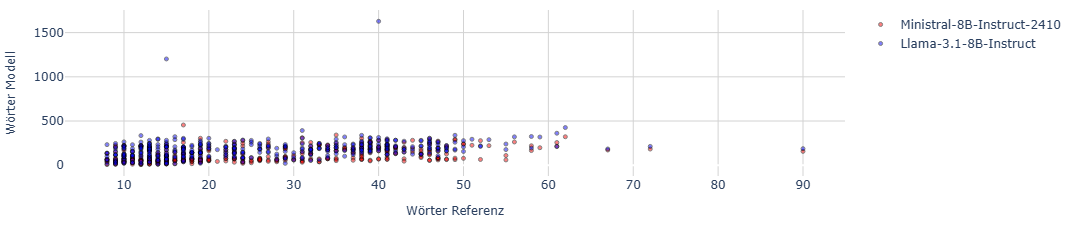

In [15]:
# Scatter-Plot Gegenüberstellung Anzahl Wörter Modell- und Referenz-Antwort
fig = go.Figure()

# Modelle
for i in range(len(models)):
    # Scatter Plot hinzufügen
    fig.add_trace(
        go.Scatter(x=queries_text_text_table_select['answer_word_count'], 
        y=answers_model[i]['answer_word_count'],
        mode='markers',
        marker={'color': model_colors[i], 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},
        #opacity=0.5,
        name=models[i])
        #trendline='ols', 
        #trendline_color_override='rgba(255, 0, 0, 1.0)').update_traces(marker={'color': 'rgba(0, 0, 0, 1.0)'})
    )#.update_traces(marker={'color': model_colors[i], 'size': 4, 'opacity': 0.5})#, 'line': {'width': 1}

    print(f'Correlation {models[i]}\n')
    print(stats.pearsonr(queries_text_text_table_select['answer_word_count'], answers_model[i]['answer_word_count']))
    print(stats.spearmanr(queries_text_text_table_select['answer_word_count'], answers_model[i]['answer_word_count']))
    print('')
    
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Wörter Modell', 'font': {'size': 12}})#, range=[0, 500], range=[0, answers_model[1]['answer_word_count'].max()]
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Wörter Referenz', 'font': {'size': 12}})

fig.update_layout(
    width=450,
    height=225,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    showlegend=True
)#

fig.show()

Entgegen der Anweisung aus dem Prompt, dass die Antworten durch das Modell nur die wichtigsten Informationen enthalten und kurz gefasst sein sollen, bestehen diese gegenüber den Referenz-Antworten aus einer deutlich höheren Anzahl an Wörtern. Mit steigender Anzahl an Wörter der Referenz-Antwort steigt die Anzahl der Wörter der Modell-Antworten an. Für das Modell Ministral-8B-Instruct-2410 ist die durchschnittliche Differenz mit 94 Wörtern gegenüber dem Modell Llama-3.1-8B-Instruct mit 155 Wörtern deutlich geringer. 

| Modell | Pearson | Spearman |
| - | - | - |
| Ministral-8B-Instruct-2410 | 0.4289 | 0.4587 |
| Llama-3.1-8B-Instruct | 0.274 | 0.3867 |

### Scatter-Plot Differenz Anzahl Wörter Modell-/Referenz-Antwort und Similarity

Gegenüberstellung Differenz der Anzahl der Wörter zwischen Modell- und Referenz-Antwort und Ähnlichkeit zwischen diesen als Scatter-Plot

Correlation Ministral-8B-Instruct-2410

PearsonRResult(statistic=np.float64(-0.21666850966997303), pvalue=np.float64(1.3287189713987409e-05))
SignificanceResult(statistic=np.float64(-0.2208371299339929), pvalue=np.float64(8.944807331345398e-06))

Correlation Llama-3.1-8B-Instruct

PearsonRResult(statistic=np.float64(-0.11222328508813602), pvalue=np.float64(0.025348479503319695))
SignificanceResult(statistic=np.float64(-0.05981619648287117), pvalue=np.float64(0.23438606597968326))



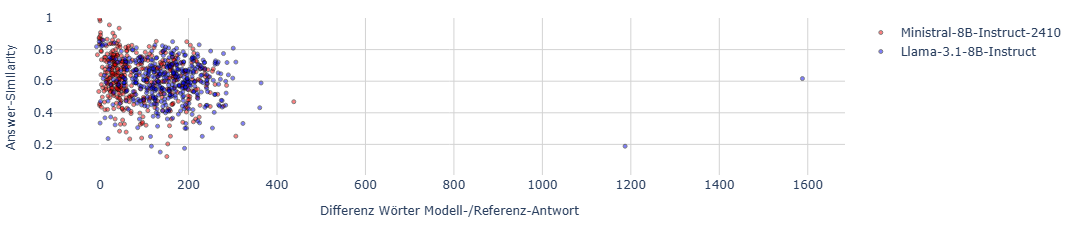

In [16]:
# Scatter-Plot Gegenüberstellung Differenz Anzahl Wörter Modell-/Referenz-Antwort und Similarity
fig = go.Figure()
# Modelle
for i in range(len(models)):
    # Scatter-Plot hinzufügen
    fig.add_trace(
        go.Scatter(
            x=answers_model[i]['answer_word_count_diff'], 
            y=answers_model[i]['answer_similarity'],
            mode='markers',
            marker={'color': model_colors[i], 'size':4, 'opacity': 0.5, 'line':{'width':1, 'color': '#000000'}},
            #opacity=0.5,
            name=models[i]
        )
    )

    print(f'Correlation {models[i]}\n')
    print(stats.pearsonr(answers_model[i]['answer_word_count_diff'], answers_model[i]['answer_similarity']))
    print(stats.spearmanr(answers_model[i]['answer_word_count_diff'], answers_model[i]['answer_similarity']))
    print('')
        
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Answer-Similarity', 'font': {'size': 12}}, dtick=0.2, range=[0.0, 1.0])
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', title={'text': 'Differenz Wörter Modell-/Referenz-Antwort', 'font': {'size': 12}}, automargin=True)#, range=[-100,1600]

fig.update_layout(
    width=450,
    height=225,
    plot_bgcolor='rgba(255, 255, 255, 1.0)', 
    paper_bgcolor='rgba(255, 255, 255, 1.0)', 
    margin={'l':10, 'b':10, 'r':10, 't':10},
    showlegend=True
)#

fig.show()

Mit Höhe der Differenz der Wortzahl zwischen Modell- und Referenz-Antwort sinkt die Ähnlichkeit zwischen diesen tendentiell.

| Modell | Pearson | Spearman 
| - | - | - |
| Ministral-8B-Instruct-2410 | -0.2167 | -0.2208 |
| Llama-3.1-8B-Instruct | -0.1122 | -0.0598 |

### Samples

Ausgabe der Ergebnisse für einzelne Beispiele

In [17]:
# Geringe Wort-Differenz und hohe Ähnlichkeit
model_select = 0

index = answers_model[model_select].loc[
    (answers_model[model_select]['answer_word_count_diff'] == 0)
].iloc[0].name

get_sample(index=index, model_select=model_select)

index: a28e8e28-85c4-43ee-9da6-23c704d72d37
---
model: Ministral-8B-Instruct-2410
---
query

Does a higher position on the grey curve indicate more or less power expenditure capacity for a rider?
---
answer reference

A higher position on the grey curve indicates more power expenditure capacity for a rider.
---
answer model

A higher position on the grey curve indicates less power expenditure capacity for a rider.
---
answer similarity: 0.9811252653454933


Die Modell-Antwort zu der Frage mit dem Index a28e8e28-85c4-43ee-9da6-23c704d72d37 stimmt mit der Referenz-Antwort bis auf ein Wort vollständig überein und die mittels Vector-Similarity berechnet Ähnlichkeit ist mit 0.9811 sehr hoch. Sie beantworten die Frage aber mit einer genau entgegengesetzten Bestätigung und das Ergebnis zeigt, dass der Vergleich nur auf lexikalischer und semantischer Ebene erfolgt. Das Verfahren ist für den Vergleich nur bedingt bzw. die Prüfung eines Merkmals wie der sachlichen Korrektheit einer Aussage nicht geeignet.

In [18]:
# Geringe Wort-Differenz und Ähnlichkeit
model_select = 1

index = answers_model[model_select].loc[
    (answers_model[model_select]['answer_word_count_diff'] == 18) & 
    (answers_model[model_select]['answer_similarity'] < 0.24)
].iloc[0].name
    
get_sample(index=index, model_select=model_select)

index: 40be6851-960d-4587-b74e-e66efb546a14
---
model: Llama-3.1-8B-Instruct
---
query

Does the equality \( S(z, 0) = S(z, 1) \) hold for all values of \( z \)?
---
answer reference

Yes, it holds for all \( z \in [0,1] \).
---
answer model

I'm not aware of any information about a function S(z, a). Could you please provide more context or information about the function S(z, a) and its domain?
---
answer similarity: 0.23675699023642177


Die zur Beantwortung der Frage mit dem Index 40be6851-960d-4587-b74e-e66efb546a14 benötigten Kontext-Informationen stehen nicht zur Verfügung und die durch das Modell erzeugte Antwort ist unter diesen Bedingungen sachlich richtig. Da sie semantisch nicht der Referenz-Antwort entspricht, ist die berechnete Ähnlichkeit mit 0.2368 aber sehr gering und auch hier zeigt sich die Unzulänglichkeit des Verfahrens.

In [19]:
# Hohe Wort-Differenz und geringe Ähnlichkeit
model_select = 0

index = answers_model[model_select].loc[
    (answers_model[model_select]['answer_word_count_diff'] == 151) & 
    (answers_model[model_select]['answer_similarity'] < 0.13)
].iloc[0].name
    
get_sample(index=index, model_select=model_select)

index: f91e9e97-ee15-4cd7-9ed1-5868af59f6cf
---
model: Ministral-8B-Instruct-2410
---
query

Does gene tree heterogeneity affect expected cost per locus in absence?
---
answer reference

No, \( C_{\mathrm{sp}}(\psi |\,\sigma) =0.5c (\sum _{\ chi } c (\ psi |\ chi ) l _{\mathrm { sp } } ( chi |\ sigma )) +0.5c (\ sum _{\ chi } c ( psi |\ chi ) l _{\mathrm { coa } } ( chi |\ sigma ))=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{sp}(ψ∣σ)=C_{ sp }\).
---
answer model

Yes, gene tree heterogeneity can affect the expected cost per locus in the absence of recombination. Here's why:

1. **Increased Genetic Diversity**: Gene tree heterogeneity means there are multiple gene trees for different loci, each with its own history of mutations and recombination events. This increases genetic diversity, making it harder to infer the ancestral state and leading to higher costs per locus.

2. **Complexity in Phylogeny Reconstruction**: The presence of multiple gene trees increases the complexity of

Einzelne Fragen des Datensatzes scheinen nicht vollständig zu sein und die Referenz-Antwort fehlerhaft (Bsp.: Index f91e9e97-ee15-4cd7-9ed1-5868af59f6cf).

In [20]:
# Hohe Wort-Differenz und Ähnlichkeit
model_select = 1

index = answers_model[model_select].loc[answers_model[model_select]['answer_word_count_diff'] == 301].iloc[0].name

get_sample(index=index, model_select=model_select)

index: a3ef06c8-38ea-4435-9127-3b633459c084
---
model: Llama-3.1-8B-Instruct
---
query

What are the benefits of using different learning rates for Vision Transformers (ViT) and language models (LLMs) in fine-tuning?
---
answer reference

Using different learning rates for Vision Transformers (ViT) and language models (LLMs) during fine-tuning is beneficial because it allows each component to be optimized according to its specific needs. ViTs require a smaller learning rate than LLMs, which helps achieve competitive accuracy while being memory- and compute-efficient. This strategy enables efficient adaptation of vision-language models for domain-specific tasks without compromising performance.
---
answer model

Using different learning rates for Vision Transformers (ViT) and language models (LLMs) in fine-tuning can provide several benefits:

1. **Improved convergence**: By adjusting the learning rates for different components, you can control the rate at which each component learns, p